In [45]:
# Importation des librairies
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import Normalizer
from sklearn.decomposition import PCA
import numpy as np
from sklearn.cluster import KMeans

df = pd.read_csv("./dataset/nba_players.csv")

unused_features = ['index', 'age','team_abbreviation', 'college', 'country', 'season', 'draft_year', 'draft_round', 'draft_number', 'player_height', 'player_weight' ]

for feature in unused_features:
    if feature in df.columns:
        df = df.drop(columns=[feature])

# Nombre d'échantillons et de features
print("Number of samples:", df.shape[0])
print("Number of features:", df.shape[1])
df = df.sort_values("player_name")
df.head(20)

Number of samples: 12844
Number of features: 11


,player_name,gp,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct
1626,A.C. Green,82,5.0,5.9,1.0,8.1,0.089,0.179,0.111,0.482,0.058
667,A.C. Green,82,7.3,8.1,1.5,-7.2,0.090,0.196,0.118,0.496,0.074
419,A.C. Green,83,7.2,7.9,0.8,-8.0,0.100,0.207,0.119,0.523,0.045
1006,A.C. Green,50,4.9,4.6,0.5,-5.6,0.097,0.179,0.148,0.441,0.043
1971,A.C. Green,82,4.5,3.8,0.5,3.3,0.089,0.171,0.141,0.492,0.050
1625,A.J. Bramlett,8,1.0,2.8,0.0,-32.6,0.158,0.208,0.146,0.190,0.000
2613,A.J. Guyton,45,5.4,1.0,1.8,-3.8,0.022,0.067,0.221,0.477,0.248
2929,A.J. Guyton,2,0.0,0.0,1.0,-3.9,0.000,0.000,0.282,0.000,0.400
1970,A.J. Guyton,33,6.0,1.1,1.9,-12.4,0.018,0.053,0.169,0.495,0.198
12588,A.J. Lawson,15,3.7,1.4,0.1,-20.1,0.046,0.152,0.189,0.589,0.032


In [46]:
df_avg = df.groupby("player_name").mean(numeric_only=False).reset_index()
df_avg = df_avg.sort_values("player_name")

# Nombre d'échantillons et de features
print("Number of samples:", df_avg.shape[0])
print("Number of features:", df_avg.shape[1])

df_avg.head(20)

Number of samples: 2551
Number of features: 11


,player_name,gp,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct
0,A.C. Green,75.800000,5.780000,6.060000,0.860000,-1.880000,0.093000,0.186400,0.127400,0.486800,0.054000
1,A.J. Bramlett,8.000000,1.000000,2.800000,0.000000,-32.600000,0.158000,0.208000,0.146000,0.190000,0.000000
2,A.J. Guyton,26.666667,3.800000,0.700000,1.566667,-6.700000,0.013333,0.040000,0.224000,0.324000,0.282000
3,A.J. Lawson,15.000000,3.700000,1.400000,0.100000,-20.100000,0.046000,0.152000,0.189000,0.589000,0.032000
4,AJ Green,35.000000,4.400000,1.300000,0.600000,-4.900000,0.016000,0.105000,0.159000,0.607000,0.092000
5,AJ Griffin,72.000000,8.900000,2.100000,1.000000,1.500000,0.026000,0.080000,0.174000,0.577000,0.070000
6,AJ Hammons,22.000000,2.200000,1.600000,0.200000,-0.600000,0.049000,0.199000,0.167000,0.472000,0.038000
7,AJ Price,43.500000,5.350000,1.333333,2.000000,-2.233333,0.017667,0.090833,0.210667,0.476500,0.248833
8,Aaron Brooks,64.500000,8.880000,1.550000,2.760000,-3.310000,0.022700,0.069700,0.222200,0.521000,0.230700
9,Aaron Gordon,66.222222,13.200000,6.266667,2.511111,1.000000,0.060667,0.163778,0.198556,0.548667,0.123222


(2551, 10)
[[9.93561655e-01 7.57623531e-02 7.94325017e-02 ... 1.66991761e-03
  6.38081549e-03 7.07814372e-04]
 [2.37384999e-01 2.96731249e-02 8.30847496e-02 ... 4.33227623e-03
  5.63789372e-03 0.00000000e+00]
 [9.58747675e-01 1.36621544e-01 2.51671265e-02 ... 8.05348047e-03
  1.16487843e-02 1.01387567e-02]
 ...
 [9.88514632e-01 7.68102586e-02 2.67166117e-02 ... 4.22790380e-03
  9.85842971e-03 4.26129956e-03]
 [9.74023107e-01 1.94342451e-01 1.10227526e-01 ... 3.45356473e-03
  7.98051909e-03 1.04219317e-03]
 [3.82102466e-02 2.29261480e-02 1.75767134e-02 ... 2.69764341e-03
  5.09724690e-03 7.18352636e-04]]


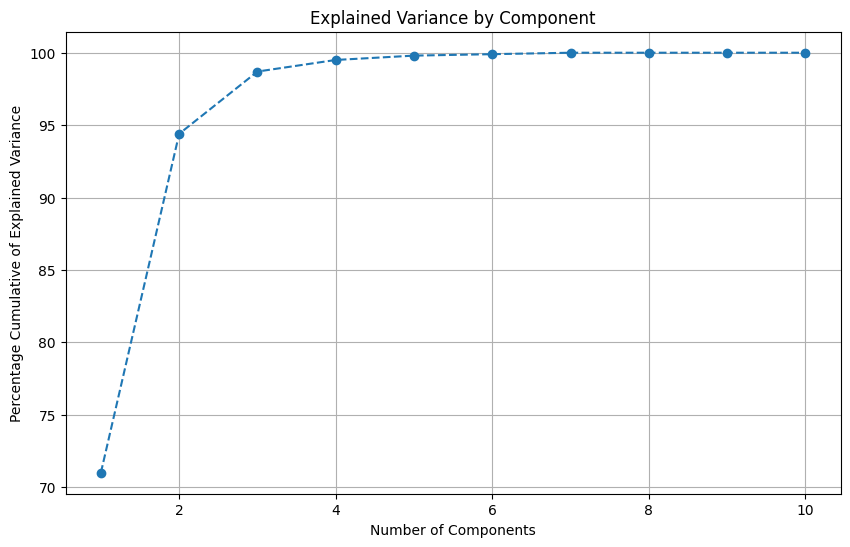

In [47]:
data = df_avg.drop(columns=["player_name"]).values

df_normalized = Normalizer().fit_transform(data)
print(df_normalized.shape)
print(df_normalized)
pca = PCA()
pca.fit(df_normalized)
per_var = np.round(pca.explained_variance_ratio_*100, decimals = 1)

plt.figure(figsize = (10,6))
plt.plot(range(1, len(per_var)+1), per_var.cumsum(), marker = "o", linestyle = "--")
plt.grid()
plt.ylabel("Percentage Cumulative of Explained Variance")
plt.xlabel("Number of Components")
plt.title("Explained Variance by Component")
plt.show()

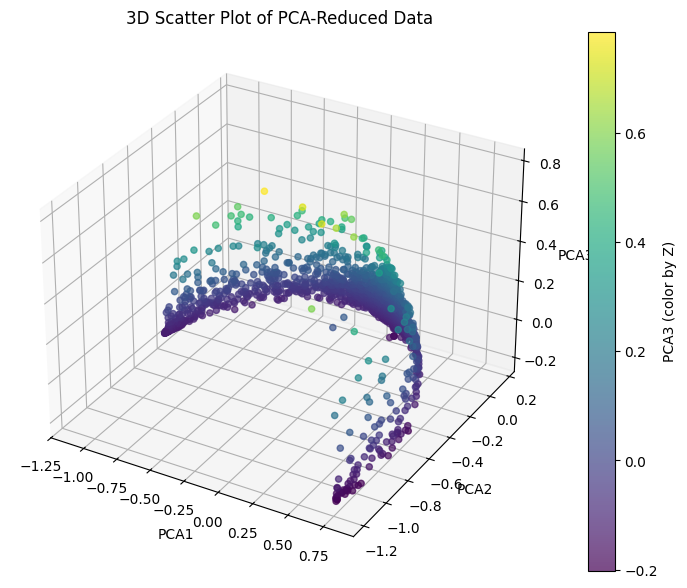

,player_name,PCA1,PCA2,PCA3
0,0,0.153550,0.090511,-0.063999
1,1,-0.997042,-0.281919,-0.066028
2,2,-0.058983,0.135215,-0.010767
3,3,-0.703460,-0.014311,0.022758
4,4,0.045239,0.119961,-0.030015
5,5,0.196312,0.073406,-0.041105
6,6,0.151394,0.089466,-0.044567
7,7,0.129001,0.096725,-0.032346
8,8,0.128992,0.095415,-0.022552
9,9,0.188647,0.059128,0.052039


In [48]:
pca = PCA(n_components = 3)
pca.fit(df_normalized)
data_pca = pca.transform(df_normalized)
df_reduced = pd.DataFrame(data_pca, columns=["PCA1", "PCA2", "PCA3"])
df_reduced.insert(0, "player_name", df_avg.index)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df_reduced["PCA1"], df_reduced["PCA2"], df_reduced["PCA3"], s=20, alpha=0.7)
sc = ax.collections[-1]
sc.set_array(df_reduced["PCA3"].values)
sc.set_cmap("viridis")
plt.colorbar(sc, ax=ax, label="PCA3 (color by Z)")
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D Scatter Plot of PCA-Reduced Data")
plt.show()

df_reduced.head(20)

In [49]:
# Find the row index with the highest PCA3 value and display details
max_idx = df_reduced["PCA3"].idxmax()
max_val = df_reduced.loc[max_idx, "PCA3"]
player = df_avg.loc[max_idx, "player_name"]

print("Highest PCA3 index:", max_idx)
print("Player:", player)
print("PCA3 value:", max_val)

Highest PCA3 index: 317
Player: Cameron Oliver
PCA3 value: 0.7855044992103788


In [50]:
score = []
for k in range(1, 20):
    model = KMeans(n_clusters=k, init='random', random_state=10)
    model.fit(df_reduced[["PCA1", "PCA2"]])
